## Aravind's contribution

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Load and Prepare Data

In [4]:
# Load datasets
df_train = pd.read_csv("cleaned_train_balanced.csv")
df_test = pd.read_csv("cleaned_test.csv")

# Remove NaNs
df_train.dropna(subset=['clean_tweet'], inplace=True)
df_test.dropna(subset=['clean_tweet'], inplace=True)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(df_train['clean_tweet']).toarray()
X_test = vectorizer.transform(df_test['clean_tweet']).toarray()

# Encode target labels
le = LabelEncoder()
y_train = le.fit_transform(df_train['sentiment'])
y_test = le.transform(df_test['sentiment'])

# Class mapping
label_map = {i: label for i, label in enumerate(le.classes_)}

### Create Dataset and DataLoader

In [5]:
class TfidfDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TfidfDataset(X_train, y_train)
test_ds = TfidfDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=64)

### BiLSTM Model Using TF-IDF

In [6]:
class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Reshape input: [batch_size, seq_len, input_dim] (here seq_len=1)
        x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])  # Use last time-step
        return self.fc(out)

### Train the Model

In [15]:
import torch.optim as optim
from tqdm import tqdm

In [17]:
def train_model(model, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss, correct, total = 0, 0, 0
        progress_bar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for X_batch, y_batch in progress_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)

            acc = correct / total
            progress_bar.set_postfix(loss=total_loss / total, acc=acc)

        print(f"Epoch {epoch+1} completed | Loss: {total_loss:.4f} | Accuracy: {acc:.4f}")

In [18]:
train_model(model, epochs=5)

Epoch 1 completed | Loss: 2022.3001 | Accuracy: 0.6844


Epoch 2 completed | Loss: 1844.1163 | Accuracy: 0.7156


Epoch 3 completed | Loss: 1769.9661 | Accuracy: 0.7282


Epoch 4 completed | Loss: 1706.2667 | Accuracy: 0.7392


Epoch 5 completed | Loss: 1639.8762 | Accuracy: 0.7504


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Evaluate Model and Print Metrics for train data

Classification Report (Training Data):
              precision    recall  f1-score   support

    Negative       0.75      0.85      0.80     61275
     Neutral       0.77      0.61      0.68     53042
    Positive       0.80      0.84      0.82     61257

    accuracy                           0.77    175574
   macro avg       0.77      0.77      0.77    175574
weighted avg       0.77      0.77      0.77    175574



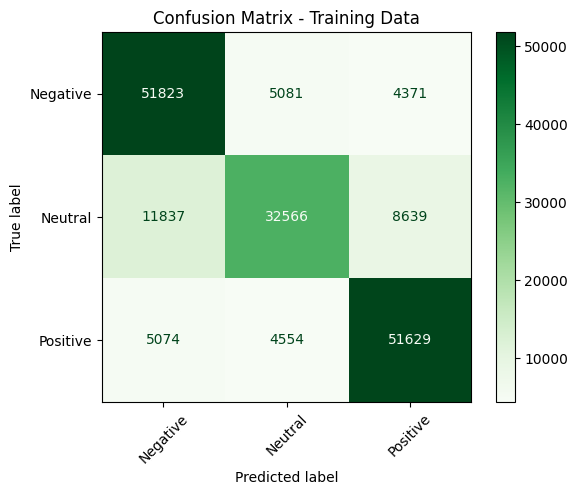

In [28]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

train_preds = []
train_labels = []

# Inference on training data (no gradient tracking)
with torch.no_grad():
    for X_batch, y_batch in train_dl:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = y_batch.cpu().numpy()

        train_preds.extend(preds)
        train_labels.extend(labels)

# Convert numeric predictions and labels to original class names
y_train_pred_labels = le.inverse_transform(train_preds)
y_train_true_labels = le.inverse_transform(train_labels)

# Print classification report
print("Classification Report (Training Data):")
print(classification_report(y_train_true_labels, y_train_pred_labels))

# Plot confusion matrix
cm = confusion_matrix(y_train_true_labels, y_train_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Greens", xticks_rotation=45)
plt.title("Confusion Matrix - Training Data")
plt.grid(False)
plt.show()

### Evaluate Model and Print Metrics for test data

In [29]:
def evaluate_model(model, dataloader, label_encoder):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    # Decode labels
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("Evaluation Metrics:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

Evaluation Metrics:
Accuracy:  0.7684
Precision: 0.8031
Recall:    0.7684
F1 Score:  0.7786

Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.81      0.67     15294
     Neutral       0.51      0.57      0.54     13195
    Positive       0.93      0.80      0.86     59558

    accuracy                           0.77     88047
   macro avg       0.67      0.73      0.69     88047
weighted avg       0.80      0.77      0.78     88047



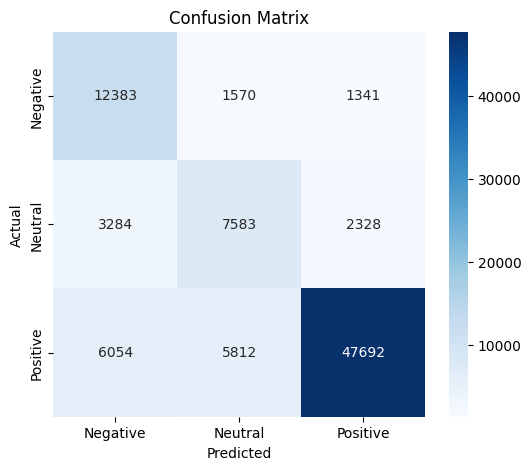

In [30]:
evaluate_model(model, test_dl, le) 

In [31]:
# Save model weights
torch.save(model.state_dict(), "bilstm_model.pth")
print("Model saved as bilstm_model.pth")

Model saved as bilstm_model.pth


## Intersting Findings
- LIME Results: Words like “tired,” “harassment,” “expected,” “crime,” “freedom” had noticeable positive and negative contributions.
- This indicates the model learned to associate emotionally charged or context-specific words with sentiment polarity — a good sign of learned semantics.

## Next Steps
- Deploy the Best Model via Web App for realtime prediction
- Use Pretrained model to predict
- Make changes in dropout and learning rate to tune model more extensively

## LLM Prompts
- First: I have to predict whether the uploaded tweet is negative, positive, or neutral. I have data in sentiment_data.csv. Give me code to load it in ipynb and next steps.
- Last: How to import model as pytorch file